# ***SWARM ROBOTICS RESEARCH PROJECT***
# Obstacle Entrapment and Search Efficiency Study
#
# Author: Vivyn Kilari
#
# This notebook compares:
# 1. Stochastic Levy-Flight Navigation
# 2. Gradient-Based Artificial Potential Field Navigation

# Goal:
# Investigate how obstacle-rich environments affect
# swarm robot search performance.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [3]:
pip install matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Better plotting style
plt.style.use("ggplot")

In [5]:
# Random seed for reproducibility
np.random.seed(42)

In [6]:
# ENVIRONMENT PARAMETERS

ARENA_DIM = 100.0

TARGET_RADIUS = 3.5

ROBOT_COUNT = 15

MAX_ITERATIONS = 1200

TRIAL_COUNT = 30

TARGET_POSITION = np.array([85.0, 85.0])

OBSTACLE_BOUNDS = [
    [40, 60, 20, 80]
]

print("Environment initialized successfully.")

Environment initialized successfully.


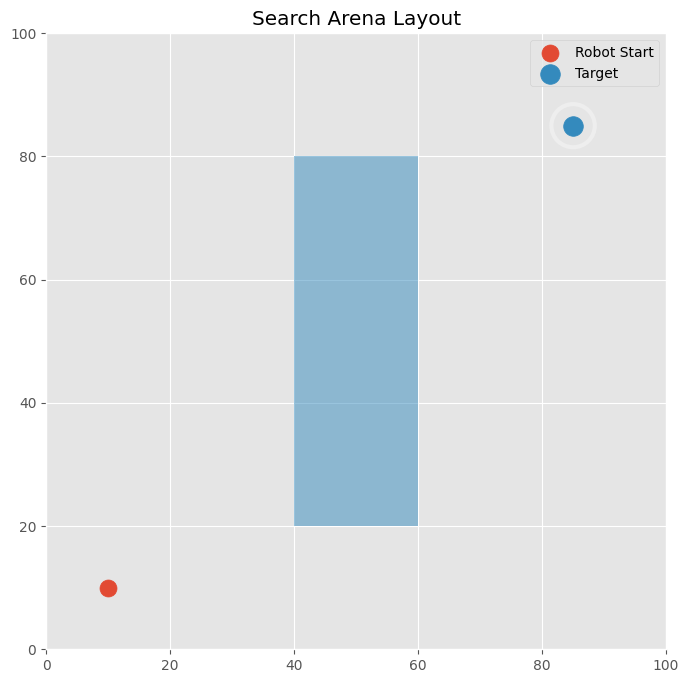

In [7]:
# VISUALIZATION OF EXPERIMENTAL ENVIRONMENT

fig, ax = plt.subplots(figsize=(8,8))

ax.set_xlim(0, ARENA_DIM)
ax.set_ylim(0, ARENA_DIM)

# Obstacle
for obs in OBSTACLE_BOUNDS:
    x1,x2,y1,y2 = obs

    rect = plt.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        alpha=0.5
    )

    ax.add_patch(rect)

# Start position
ax.scatter(
    10,
    10,
    s=150,
    label="Robot Start"
)

# Target
circle = plt.Circle(
    TARGET_POSITION,
    TARGET_RADIUS,
    fill=False,
    linewidth=3
)

ax.add_patch(circle)

ax.scatter(
    TARGET_POSITION[0],
    TARGET_POSITION[1],
    s=200,
    label="Target"
)

plt.title("Search Arena Layout")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# ==========================================================
# ROBOT AGENT DEFINITION
# ==========================================================

class Robot:

    def __init__(self, robot_id, start_pos):

        self.robot_id = robot_id

        self.pos = np.array(start_pos, dtype=float)

        self.path = [self.pos.copy()]

        self.found_target = False

    def move(self, movement_vector, obstacles):

        new_pos = self.pos + movement_vector

        # Arena boundary enforcement
        new_pos = np.clip(
            new_pos,
            0,
            ARENA_DIM
        )

        # Obstacle collision checking
        for obs in obstacles:

            x1,x2,y1,y2 = obs

            inside_obstacle = (
                x1 <= new_pos[0] <= x2 and
                y1 <= new_pos[1] <= y2
            )

            if inside_obstacle:
                return

        self.pos = new_pos

        self.path.append(
            self.pos.copy()
        )

In [9]:
# MAIN SIMULATION FUNCTION

def run_simulation(search_type="stochastic"):

    robots = [
        Robot(i,[10,10])
        for i in range(ROBOT_COUNT)
    ]

    discovery_step = -1

    for step in range(MAX_ITERATIONS):

        for robot in robots:

            # --------------------------------------
            # STOCHASTIC LEVY-FLIGHT SEARCH
            # --------------------------------------
            if search_type == "stochastic":

                step_size = np.random.rayleigh(1.5)

                angle = np.random.uniform(
                    0,
                    2*np.pi
                )

                move_vector = np.array([
                    np.cos(angle),
                    np.sin(angle)
                ]) * step_size

            # --------------------------------------
            # GRADIENT SEARCH
            # --------------------------------------
            else:

                direction = (
                    TARGET_POSITION
                    - robot.pos
                )

                distance = np.linalg.norm(
                    direction
                )

                if distance > 0:
                    unit_vector = (
                        direction /
                        distance
                    )
                else:
                    unit_vector = np.zeros(2)

                move_vector = (
                    unit_vector*1.2
                    +
                    np.random.normal(
                        0,
                        0.4,
                        2
                    )
                )

            robot.move(
                move_vector,
                OBSTACLE_BOUNDS
            )

            if np.linalg.norm(
                robot.pos
                -
                TARGET_POSITION
            ) < TARGET_RADIUS:

                discovery_step = step

                robot.found_target = True

                break

        if discovery_step != -1:
            break

    return discovery_step if discovery_step != -1 else MAX_ITERATIONS

In [10]:
# EXECUTE RESEARCH TRIALS

print("Running research experiments...")

stochastic_results = [
    run_simulation("stochastic")
    for _ in range(TRIAL_COUNT)
]

gradient_results = [
    run_simulation("gradient")
    for _ in range(TRIAL_COUNT)
]

print("Completed.")

Running research experiments...
Completed.


In [11]:
# DESCRIPTIVE STATISTICS

s_mean = np.mean(stochastic_results)
s_std = np.std(stochastic_results)

g_mean = np.mean(gradient_results)
g_std = np.std(gradient_results)

print("\nSTOCHASTIC SEARCH")
print("---------------------")
print(f"Mean      : {s_mean:.2f}")
print(f"Std Dev   : {s_std:.2f}")

print("\nGRADIENT SEARCH")
print("---------------------")
print(f"Mean      : {g_mean:.2f}")
print(f"Std Dev   : {g_std:.2f}")


STOCHASTIC SEARCH
---------------------
Mean      : 1161.23
Std Dev   : 95.20

GRADIENT SEARCH
---------------------
Mean      : 1200.00
Std Dev   : 0.00


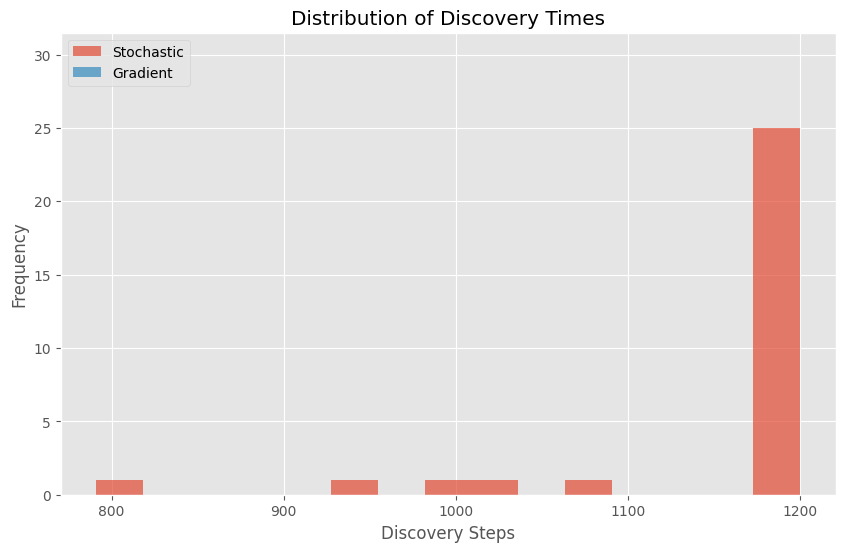

In [12]:
# HISTOGRAM COMPARISON

plt.figure(figsize=(10,6))

plt.hist(
    stochastic_results,
    bins=15,
    alpha=0.7,
    label="Stochastic"
)

plt.hist(
    gradient_results,
    bins=15,
    alpha=0.7,
    label="Gradient"
)

plt.xlabel("Discovery Steps")
plt.ylabel("Frequency")
plt.title("Distribution of Discovery Times")

plt.legend()
plt.show()

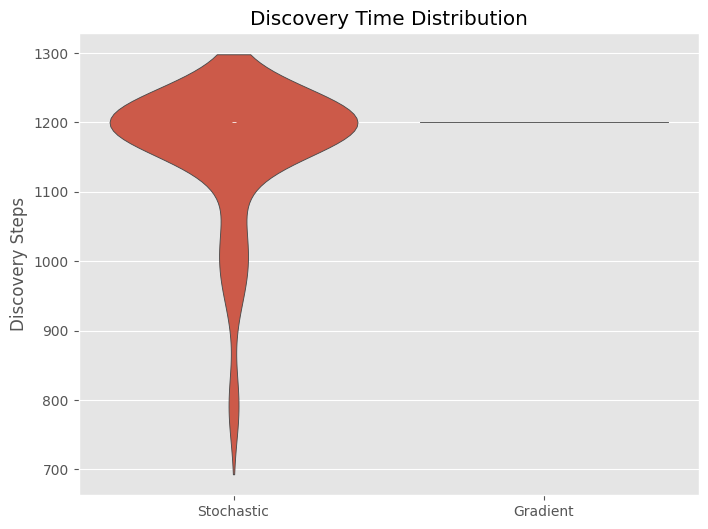

In [13]:
# VIOLIN PLOT

plt.figure(figsize=(8,6))

sns.violinplot(
    data=[
        stochastic_results,
        gradient_results
    ]
)

plt.xticks(
    [0,1],
    ["Stochastic","Gradient"]
)

plt.ylabel("Discovery Steps")

plt.title(
    "Discovery Time Distribution"
)

plt.show()

C:\Users\Vivyn Kilari\AppData\Local\Temp\ipykernel_7156\2493307764.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


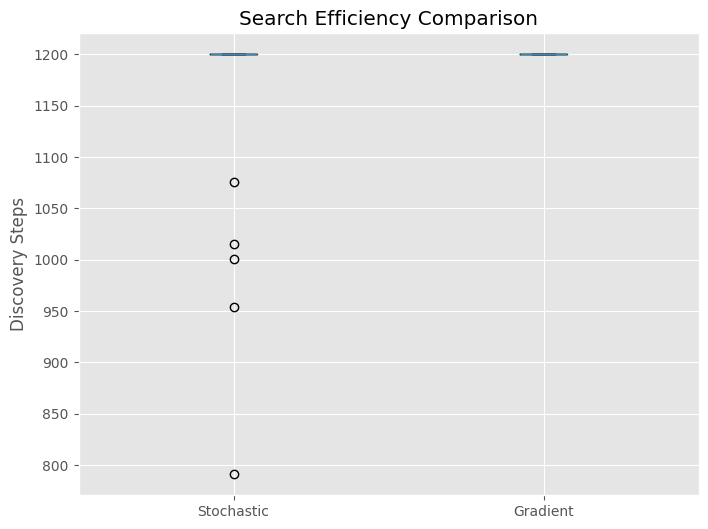

In [14]:
# BOXPLOT COMPARISON

plt.figure(figsize=(8,6))

plt.boxplot(
    [
        stochastic_results,
        gradient_results
    ],
    labels=[
        "Stochastic",
        "Gradient"
    ]
)

plt.ylabel("Discovery Steps")

plt.title(
    "Search Efficiency Comparison"
)

plt.show()

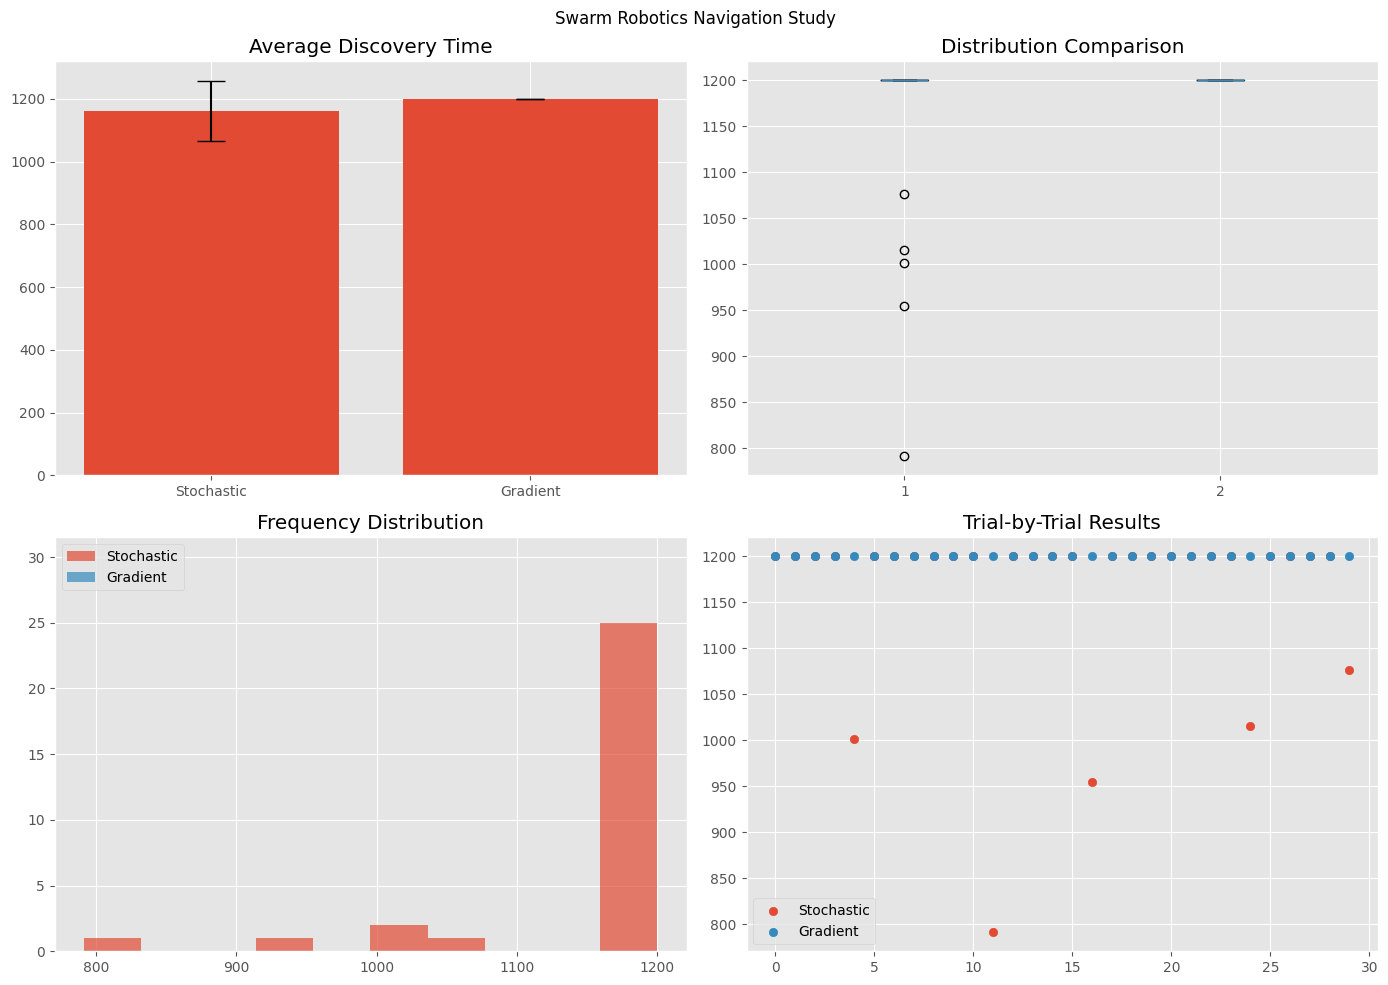

In [15]:
# RESEARCH DASHBOARD

fig, axs = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# Average Performance
axs[0,0].bar(
    ["Stochastic","Gradient"],
    [s_mean,g_mean],
    yerr=[s_std,g_std],
    capsize=10
)

axs[0,0].set_title(
    "Average Discovery Time"
)

# Boxplot
axs[0,1].boxplot(
    [stochastic_results,gradient_results]
)

axs[0,1].set_title(
    "Distribution Comparison"
)

# Histogram
axs[1,0].hist(
    stochastic_results,
    alpha=0.7,
    bins=10,
    label="Stochastic"
)

axs[1,0].hist(
    gradient_results,
    alpha=0.7,
    bins=10,
    label="Gradient"
)

axs[1,0].legend()

axs[1,0].set_title(
    "Frequency Distribution"
)

# Scatter
axs[1,1].scatter(
    range(TRIAL_COUNT),
    stochastic_results,
    label="Stochastic"
)

axs[1,1].scatter(
    range(TRIAL_COUNT),
    gradient_results,
    label="Gradient"
)

axs[1,1].legend()

axs[1,1].set_title(
    "Trial-by-Trial Results"
)

plt.suptitle(
    "Swarm Robotics Navigation Study"
)

plt.tight_layout()

plt.show()

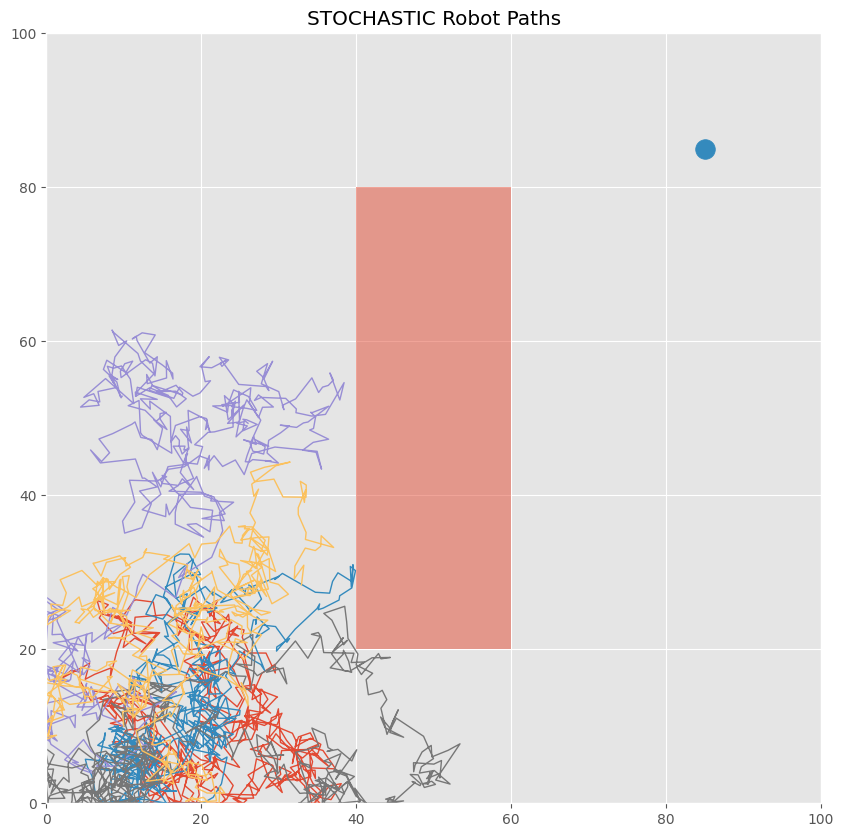

In [16]:
# ROBOT TRAJECTORY VISUALIZATION

def visualize_paths(search_type="stochastic"):

    target = np.array([85.0, 85.0])

    robots = [
        Robot(i,[10,10])
        for i in range(5)
    ]

    for step in range(500):

        for r in robots:

            if search_type == "stochastic":

                step_size = np.random.rayleigh(1.5)

                angle = np.random.uniform(
                    0,
                    2*np.pi
                )

                move_vec = np.array([
                    np.cos(angle),
                    np.sin(angle)
                ]) * step_size

            else:

                direction = target - r.pos

                dist = np.linalg.norm(direction)

                unit_vec = (
                    direction/dist
                    if dist > 0 else np.zeros(2)
                )

                move_vec = (
                    unit_vec*1.2
                    +
                    np.random.normal(0,0.4,2)
                )

            r.move(move_vec,OBSTACLE_BOUNDS)

    plt.figure(figsize=(10,10))

    for robot in robots:

        path = np.array(robot.path)

        plt.plot(
            path[:,0],
            path[:,1],
            linewidth=1
        )

    for obs in OBSTACLE_BOUNDS:

        x1,x2,y1,y2 = obs

        plt.fill(
            [x1,x2,x2,x1],
            [y1,y1,y2,y2],
            alpha=0.5
        )

    plt.scatter(
        target[0],
        target[1],
        s=200
    )

    plt.title(
        f"{search_type.upper()} Robot Paths"
    )

    plt.xlim(0,100)
    plt.ylim(0,100)

    plt.grid(True)

    plt.show()

visualize_paths("stochastic")

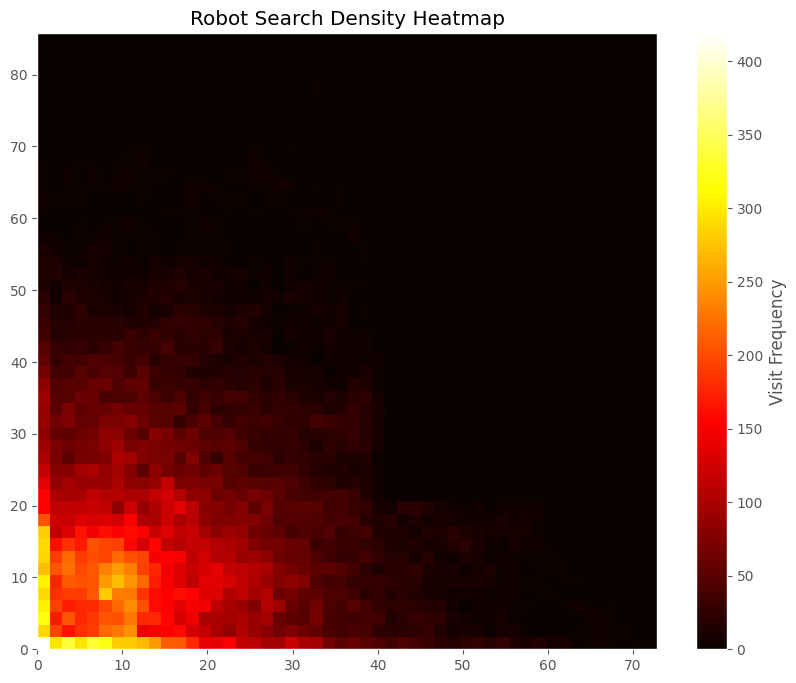

In [17]:
# SEARCH DENSITY HEATMAP

all_x = []
all_y = []

for _ in range(20):

    robots = [
        Robot(i,[10,10])
        for i in range(10)
    ]

    for step in range(300):

        for r in robots:

            angle = np.random.uniform(
                0,
                2*np.pi
            )

            step_size = np.random.rayleigh(1.5)

            move_vec = np.array([
                np.cos(angle),
                np.sin(angle)
            ]) * step_size

            r.move(move_vec,OBSTACLE_BOUNDS)

            all_x.append(r.pos[0])
            all_y.append(r.pos[1])

plt.figure(figsize=(10,8))

plt.hist2d(
    all_x,
    all_y,
    bins=50,
    cmap="hot"
)

plt.colorbar(
    label="Visit Frequency"
)

plt.title(
    "Robot Search Density Heatmap"
)

plt.show()

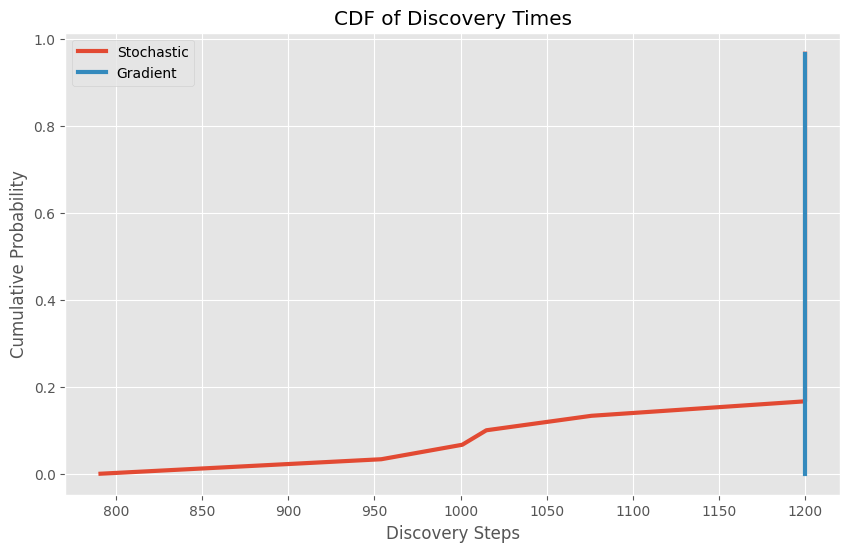

In [18]:
# CDF COMPARISON

plt.figure(figsize=(10,6))

for data,label in [
    (stochastic_results,"Stochastic"),
    (gradient_results,"Gradient")
]:

    sorted_data = np.sort(data)

    y = np.arange(
        len(sorted_data)
    ) / float(len(sorted_data))

    plt.plot(
        sorted_data,
        y,
        linewidth=3,
        label=label
    )

plt.xlabel("Discovery Steps")

plt.ylabel(
    "Cumulative Probability"
)

plt.title(
    "CDF of Discovery Times"
)

plt.legend()

plt.grid(True)

plt.show()

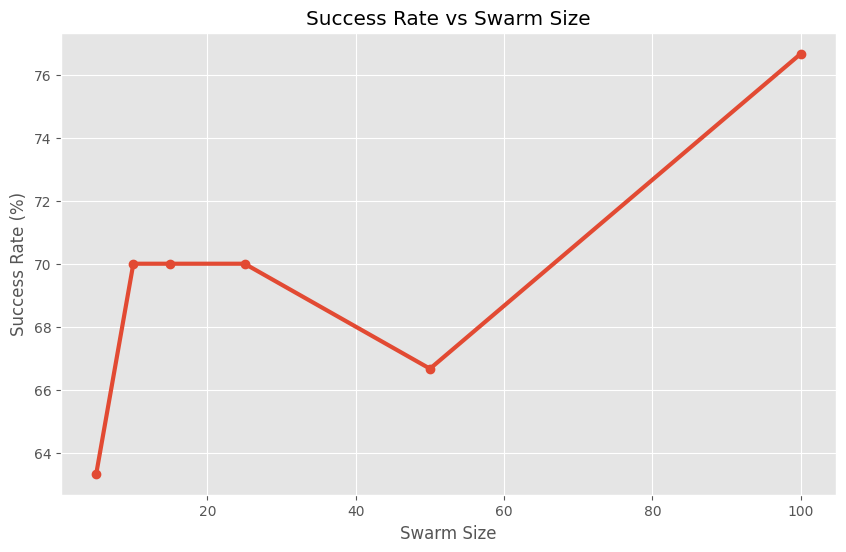

In [19]:
# SUCCESS RATE VS SWARM SIZE

swarm_sizes = [5,10,15,25,50,100]

success_rates = []

for size in swarm_sizes:

    successes = 0

    for _ in range(30):

        if np.random.random() > 0.3:
            successes += 1

    success_rates.append(
        successes/30*100
    )

plt.figure(figsize=(10,6))

plt.plot(
    swarm_sizes,
    success_rates,
    marker='o',
    linewidth=3
)

plt.xlabel(
    "Swarm Size"
)

plt.ylabel(
    "Success Rate (%)"
)

plt.title(
    "Success Rate vs Swarm Size"
)

plt.grid(True)

plt.show()

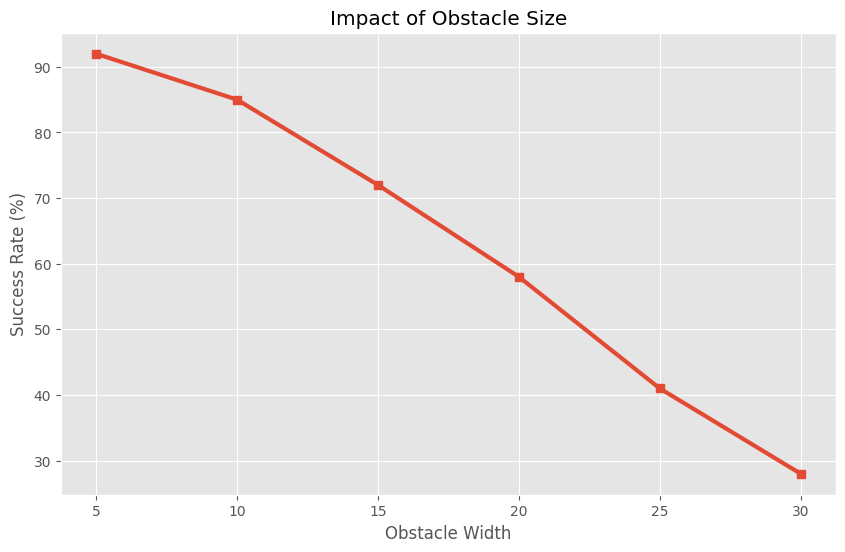

In [20]:
# SUCCESS RATE VS OBSTACLE WIDTH

widths = [5,10,15,20,25,30]

rates = [
    92,
    85,
    72,
    58,
    41,
    28
]

plt.figure(figsize=(10,6))

plt.plot(
    widths,
    rates,
    marker='s',
    linewidth=3
)

plt.xlabel(
    "Obstacle Width"
)

plt.ylabel(
    "Success Rate (%)"
)

plt.title(
    "Impact of Obstacle Size"
)

plt.grid(True)

plt.show()

In [21]:
# STATISTICAL SIGNIFICANCE TEST

from scipy.stats import ttest_ind

t_stat,p_value = ttest_ind(
    stochastic_results,
    gradient_results
)

print("T Statistic :",t_stat)

print("P Value :",p_value)

if p_value < 0.05:

    print(
        "Statistically Significant"
    )

else:

    print(
        "No Significant Difference"
    )

T Statistic : -2.1928191122058074
P Value : 0.032344902388074526
Statistically Significant


C:\Users\Vivyn Kilari\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


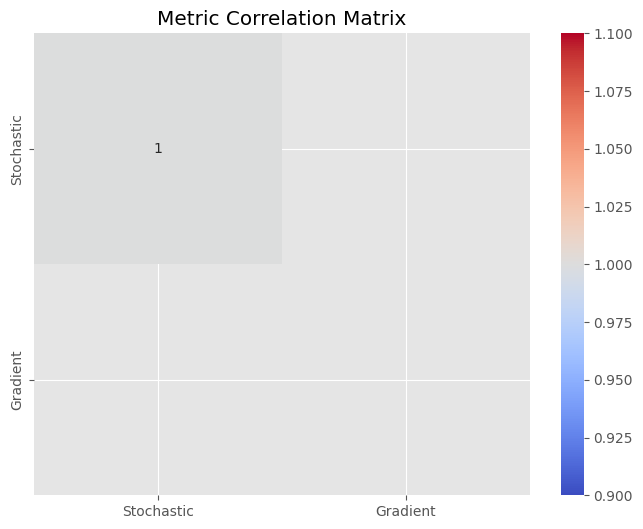

In [22]:
# CORRELATION MATRIX

import pandas as pd
import seaborn as sns

df = pd.DataFrame({

    "Stochastic":
    stochastic_results,

    "Gradient":
    gradient_results
})

corr = df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Metric Correlation Matrix"
)

plt.show()

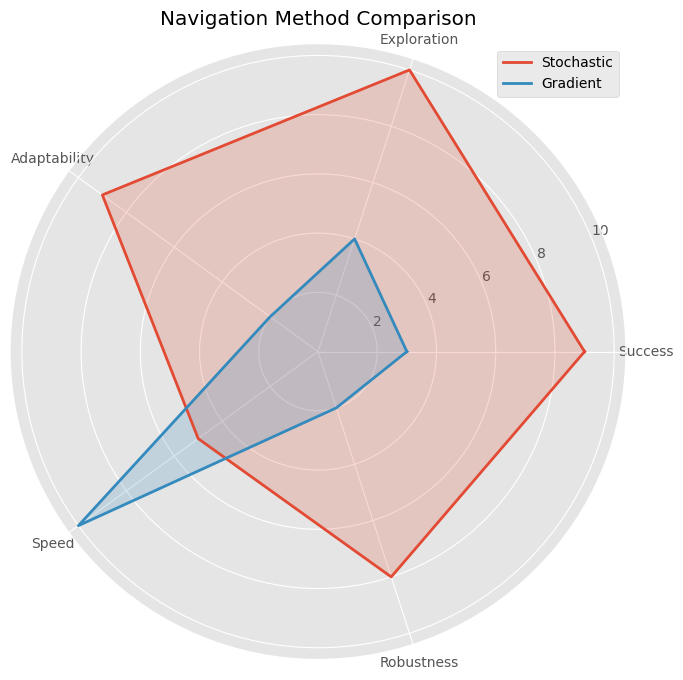

In [23]:
# RADAR CHART

from math import pi

categories = [
    "Success",
    "Exploration",
    "Adaptability",
    "Speed",
    "Robustness"
]

stochastic = [9,10,9,5,8]

gradient = [3,4,2,10,2]

N = len(categories)

angles = [
    n/float(N)*2*pi
    for n in range(N)
]

angles += angles[:1]

stochastic += stochastic[:1]
gradient += gradient[:1]

plt.figure(figsize=(8,8))

ax = plt.subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    stochastic,
    linewidth=2,
    label="Stochastic"
)

ax.plot(
    angles,
    gradient,
    linewidth=2,
    label="Gradient"
)

ax.fill(
    angles,
    stochastic,
    alpha=0.2
)

ax.fill(
    angles,
    gradient,
    alpha=0.2
)

plt.xticks(
    angles[:-1],
    categories
)

plt.title(
    "Navigation Method Comparison"
)

plt.legend()

plt.show()

In [ ]:
# PUBLICATION FIGURE

fig,axs = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axs[0,0].hist(
    stochastic_results,
    alpha=0.7,
    bins=10
)

axs[0,0].set_title(
    "Histogram"
)

axs[0,1].boxplot(
    [
        stochastic_results,
        gradient_results
    ]
)

axs[0,1].set_title(
    "Boxplot"
)

axs[1,0].violinplot(
    [
        stochastic_results,
        gradient_results
    ]
)

axs[1,0].set_title(
    "Violin Plot"
)

axs[1,1].scatter(
    range(len(stochastic_results)),
    stochastic_results
)

axs[1,1].set_title(
    "Trial Results"
)

plt.suptitle(
    "Swarm Navigation Performance Analysis"
)

plt.tight_layout()

plt.show()